# Nivel 1. Comprensión de datos y encuadre del problema

**Objetivo de negocio.** En una planta de flotación, la calidad del concentrado (`% Silica Concentrate`)
se mide en laboratorio con retraso. Ese retraso impide que los operadores corrijan el proceso a tiempo.
El objetivo es predecir la sílice del concentrado a nivel horario con información disponible antes del
resultado de laboratorio, para habilitar decisiones más tempranas.

El autor del dataset en Kaggle declara la misma intención: predecir la impureza (sílice) del concentrado
para dar información anticipada a los ingenieros, con un beneficio ambiental directo, ya que menos
mineral fuera de especificación termina en relaves. Según su descripción, las columnas 2 y 3 son la
calidad de la pulpa antes de la flotación, las columnas 4 a 8 son las variables que más impactan la
calidad final y las columnas 9 a 22 son los niveles y flujos de aire de las columnas de flotación.
El autor deja tres preguntas abiertas a la comunidad:

1. ¿Se puede predecir el % de sílice en el concentrado cada minuto?
2. ¿Cuántas horas hacia adelante se puede predecir?
3. ¿Se puede predecir sin usar la columna `% Iron Concentrate`?

Este trabajo responde las tres. Las respuestas quedan consolidadas en la sección 10 de este notebook y
el análisis que las sustenta está en el notebook 02.

Target: `% Silica Concentrate` (regresión). Este notebook establece la comprensión del dataset:
estructura, frecuencias de muestreo, calidad de datos, cobertura temporal, fuga de datos, la decisión de
agregación horaria, las métricas de evaluación y los baselines con validación temporal. La lógica
reutilizable vive en `src/`; el notebook narra e interpreta.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "config" / "config.yaml").exists():
    if _root == _root.parent:
        raise RuntimeError("No se encontro la raiz del proyecto")
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config, resolve, set_seeds
from src.data.load import load_raw, drop_exact_duplicates
from src.data.preprocess import aggregate_hourly, hourly_gaps, load_processed
from src.models.splits import chronological_split
from src.models.baseline import persistence_forecast, moving_average_forecast
from src.models.evaluate import regression_metrics, metrics_table

cfg = load_config()
set_seeds(cfg["seed"])
sns.set_theme(style="whitegrid", context="notebook")
TARGET = cfg["data"]["target"]
FIG = resolve(cfg["paths"]["figures_dir"])

## 1. Carga cruda y estructura

El CSV usa coma decimal y comillas en los valores numéricos; `src/data/load.py` lo maneja.

In [2]:
raw = load_raw(cfg)
print("Filas x columnas:", raw.shape)
print("Rango temporal:", raw['date'].min(), "->", raw['date'].max())
print("Columnas:", len(raw.columns))
raw.head(3)

Filas x columnas: (737453, 24)
Rango temporal: 2017-03-10 01:00:00 -> 2017-09-09 23:00:00
Columnas: 24


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74000,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3185.55,586.182,404.648,10.1139,1.73614,250.488,250.488,...,248.950,450.139,510.332,461.638,422.888,451.528,510.098,513.904,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3182.03,595.947,407.168,10.1135,1.73545,250.620,252.334,...,251.499,440.530,518.600,465.414,405.704,433.686,513.794,512.252,66.91,1.31


In [3]:
raw.dtypes.to_frame("dtype")

,dtype
date,datetime64[ns]
% Iron Feed,float64
% Silica Feed,float64
Starch Flow,float64
Amina Flow,float64
Ore Pulp Flow,float64
Ore Pulp pH,float64
Ore Pulp Density,float64
Flotation Column 01 Air Flow,float64
Flotation Column 02 Air Flow,float64


## 2. Frecuencias de muestreo múltiples

La columna `date` tiene resolución horaria, pero cada hora contiene muchas filas: los sensores de
proceso se muestrean a alta frecuencia mientras que la calidad de laboratorio se reporta por hora.

In [4]:
rows_per_hour = raw.groupby('date').size()
print("Filas por hora -> min %d | mediana %d | max %d" % (
    rows_per_hour.min(), int(rows_per_hour.median()), rows_per_hour.max()))
print("Segundos por muestra implícitos:", round(3600 / rows_per_hour.median(), 1))
print("Horas con != 180 filas:", int((rows_per_hour != 180).sum()),
      "->", rows_per_hour[rows_per_hour != 180].to_dict())
print("Timestamps horarios distintos:", raw['date'].nunique())

Filas por hora -> min 174 | mediana 180 | max 180
Segundos por muestra implícitos: 20.0
Horas con != 180 filas: 2 -> {Timestamp('2017-03-10 01:00:00'): 174, Timestamp('2017-04-10 00:00:00'): 179}
Timestamps horarios distintos: 4097


Cada hora trae ~180 filas, es decir un muestreo de ~20 segundos. Dos horas tienen menos filas (174 y
179). La consecuencia es que el target de laboratorio aparece replicado dentro de la hora. Antes de
decidir la agregación conviene verificar cómo se replica el target dentro de cada hora.

In [5]:
def within_hour_profile(col):
    # Cuenta en cuántas horas la columna es constante a lo largo de sus ~180 filas.
    g = raw.groupby('date')[col].nunique()
    const = int((g == 1).sum())
    return const, len(g), g

for col in [TARGET, '% Iron Concentrate', '% Iron Feed', 'Amina Flow']:
    const, total, _ = within_hour_profile(col)
    print("%-22s horas constantes dentro de la hora: %4d / %d" % (col, const, total))

gmean = raw.groupby('date')[TARGET].mean()
gfirst = raw.groupby('date')[TARGET].first()
gstd = raw.groupby('date')[TARGET].std()
print()
print("Target: corr(media_horaria, primer_valor) = %.4f" % gmean.corr(gfirst))
print("Target: std intra-hora promedio = %.4f  (std global = %.3f)" % (gstd.mean(), raw[TARGET].std()))

% Silica Concentrate   horas constantes dentro de la hora: 3787 / 4097
% Iron Concentrate     horas constantes dentro de la hora: 3881 / 4097


% Iron Feed            horas constantes dentro de la hora: 4097 / 4097


Amina Flow             horas constantes dentro de la hora:    4 / 4097



Target: corr(media_horaria, primer_valor) = 0.9997
Target: std intra-hora promedio = 0.0069  (std global = 1.126)


El target es bimodal dentro de la hora: en ~92% de las horas es constante y en ~8% varía a lo largo de
las 180 filas. Esa variación intra-hora es despreciable: la std intra-hora promedio (~0.007) es menos
del 1% de la std global del target (~1.13), y la media horaria correlaciona 0.998 con el primer valor.
Las variables de alimentación de laboratorio (`% Iron/Silica Feed`) son constantes dentro de cada hora.

**Decisión: agregar a nivel horario.** Para los 19 sensores de alta frecuencia se toma
media/std/min/max por hora, capturando nivel y variabilidad intra-hora; para el target y los feeds, la
media horaria. Cada fila pasa a ser una observación real del target y desaparece la replicación de 180x.

## 3. Calidad de datos

In [6]:
print("Valores nulos totales:", int(raw.isna().sum().sum()))
dups = int(raw.duplicated().sum())
print("Filas exactamente duplicadas: %d (%.2f%%)" % (dups, 100 * dups / len(raw)))

# Las horas cuyas ~180 filas son idénticas colapsan a 1 muestra tras deduplicar.
deduped, n_removed = drop_exact_duplicates(raw)
samples_after = deduped.groupby('date').size()
frozen = samples_after[samples_after == 1]
print("Filas removidas por deduplicación:", n_removed)
print("Horas que quedan con 1 sola muestra (sensor congelado):", list(frozen.index.astype(str)))

Valores nulos totales: 0


Filas exactamente duplicadas: 1171 (0.16%)


Filas removidas por deduplicación: 1171
Horas que quedan con 1 sola muestra (sensor congelado): ['2017-07-11 07:00:00', '2017-07-11 08:00:00', '2017-07-11 09:00:00', '2017-07-13 15:00:00']


In [7]:
# Rangos físicamente posibles: pH en [0,14], flujos y niveles no negativos, porcentajes en [0,100].
checks = {
    'Ore Pulp pH fuera de [0,14]': int(((raw['Ore Pulp pH'] < 0) | (raw['Ore Pulp pH'] > 14)).sum()),
    'Flujos/niveles negativos': int((raw[[c for c in raw.columns if 'Flow' in c or 'Level' in c]] < 0).sum().sum()),
    '% fuera de [0,100]': int((raw[[c for c in raw.columns if c.startswith('%')]].lt(0) |
                               raw[[c for c in raw.columns if c.startswith('%')]].gt(100)).sum().sum()),
}
for k, v in checks.items():
    print("%-32s %d" % (k, v))
raw.describe().T[['min', 'mean', 'max']].round(2)

Ore Pulp pH fuera de [0,14]      0
Flujos/niveles negativos         0
% fuera de [0,100]               0


,min,mean,max
date,2017-03-10 01:00:00,2017-06-16 03:27:22.656549376,2017-09-09 23:00:00
% Iron Feed,42.74,56.294739,65.78
% Silica Feed,1.31,14.651716,33.4
Starch Flow,0.002026,2869.140569,6300.23
Amina Flow,241.669,488.144697,739.538
Ore Pulp Flow,376.249,397.578372,418.641
Ore Pulp pH,8.75334,9.767639,10.8081
Ore Pulp Density,1.51982,1.68038,1.85325
Flotation Column 01 Air Flow,175.51,280.151856,373.871
Flotation Column 02 Air Flow,175.156,277.159965,375.992


No hay nulos. Hay 1171 filas exactamente duplicadas (0.16% del total): con 24 columnas float
coincidiendo al detalle no son coincidencia sino artefactos de registro (lecturas congeladas). Se
eliminan antes de agregar para no sesgar las estadísticas horarias; cuatro horas quedan con una sola
muestra (sensor congelado toda la hora) y su std intra-hora se fija en 0. No se detectan valores
físicamente imposibles.

## 4. Cobertura temporal y huecos

In [8]:
hourly = load_processed(cfg)  # construye y cachea el dataset horario si no existe
gaps = hourly_gaps(hourly)
print("Observaciones horarias:", len(hourly))
print("Huecos horarios (> 1h):")
print(gaps.to_string(index=False))

Observaciones horarias: 4097
Huecos horarios (> 1h):
          gap_start             gap_end  missing_hours
2017-03-16 06:00:00 2017-03-29 12:00:00            318


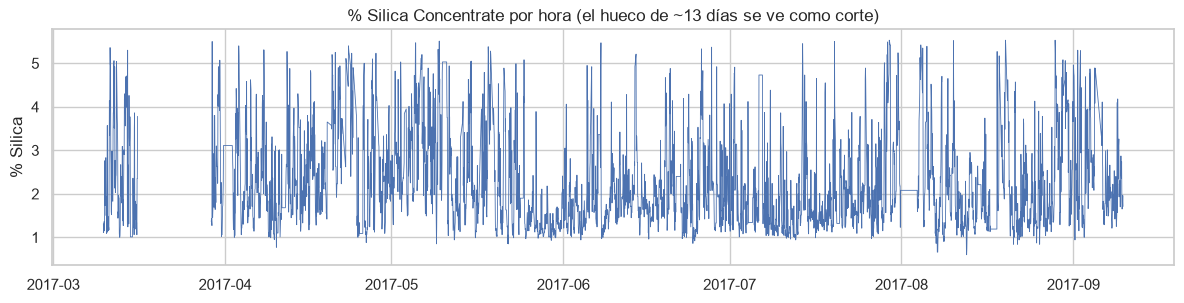

In [9]:
full_idx = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h')
series = hourly[TARGET].reindex(full_idx)  # NaN en el hueco: la línea se corta sola
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(series.index, series.values, lw=0.6)
ax.set_title('% Silica Concentrate por hora (el hueco de ~13 días se ve como corte)')
ax.set_ylabel('% Silica')
fig.tight_layout(); fig.savefig(FIG / '01_target_timeline.png', dpi=110); plt.show()

Existe un único hueco horario: del 16 de marzo (06:00) al 29 de marzo (12:00), unas 318 horas. No se
interpola a través de él; al construir lags y ventanas sobre el timeline horario completo, los bordes
del hueco generan NaN y se descartan, evitando arrastrar información a través del corte.

## 5. Fuga de datos: `% Iron Concentrate`

corr(% Iron Concentrate, % Silica Concentrate) = -0.8006
Suma Iron+Silica Concentrate: media 67.38 | std 0.71


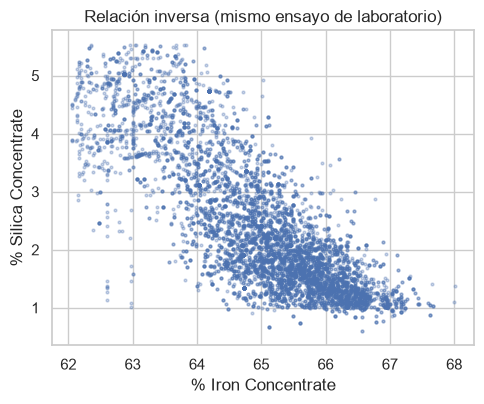

In [10]:
corr = raw['% Iron Concentrate'].corr(raw[TARGET])
ssum = (raw['% Iron Concentrate'] + raw[TARGET])
print("corr(%% Iron Concentrate, %% Silica Concentrate) = %.4f" % corr)
print("Suma Iron+Silica Concentrate: media %.2f | std %.2f" % (ssum.mean(), ssum.std()))

fig, ax = plt.subplots(figsize=(5, 4.2))
samp = raw.sample(8000, random_state=cfg['seed'])
ax.scatter(samp['% Iron Concentrate'], samp[TARGET], s=4, alpha=0.3)
ax.set_xlabel('% Iron Concentrate'); ax.set_ylabel('% Silica Concentrate')
ax.set_title('Relación inversa (mismo ensayo de laboratorio)')
fig.tight_layout(); fig.savefig(FIG / '01_leakage_iron_silica.png', dpi=110); plt.show()

`% Iron Concentrate` proviene del mismo ensayo de laboratorio que el target: se mide junto con él y se
conoce recién cuando llega el resultado, no en tiempo real. Su correlación con el target es fuerte y
negativa (-0.80, no el -0.97 que a veces se cita) y juntas suman ~67%, no ~100%. Independientemente de
la magnitud exacta, usarla como feature constituye fuga: filtra el resultado que se quiere anticipar.
**Se excluye del modelo.** El notebook 02 incluye el experimento con y sin esta variable para
cuantificar el inflado.

En cambio, `% Iron Feed` y `% Silica Feed` son mediciones de laboratorio del alimento (entradas del
proceso, conocidas antes del resultado): son features válidas, bajo el supuesto documentado de que
están disponibles al momento de predecir.

## 6. Matriz de diseño horaria

In [11]:
print("Dataset horario:", hourly.shape)
feat_cols = [c for c in hourly.columns if c not in (TARGET, 'n_samples')]
print("Columnas de features base:", len(feat_cols))
groups = pd.Series([c.split('__')[1] if '__' in c else 'lab_feed' for c in feat_cols]).value_counts()
print("Por tipo de agregación:\n", groups.to_string())
print("'% Iron Concentrate' presente:", '% Iron Concentrate' in hourly.columns)
hourly[[TARGET, 'n_samples'] + feat_cols[:3]].head(3)

Dataset horario: (4097, 81)
Columnas de features base: 79
Por tipo de agregación:
 mean        19
min         19
std         19
max         19
lab_feed     3
'% Iron Concentrate' presente: True


,% Silica Concentrate,n_samples,% Iron Feed,% Silica Feed,Starch Flow__mean
date,,,,,
2017-03-10 01:00:00,1.31,174,55.2,16.98,3162.625026
2017-03-10 02:00:00,1.11,180,55.2,16.98,3133.256389
2017-03-10 03:00:00,1.27,180,55.2,16.98,3479.482944


Resultan 4097 observaciones horarias con 78 columnas base: 19 sensores por {media, std, min, max} son
76, más 2 feeds de laboratorio. El target y `n_samples` (metadato de calidad) no son features, y
`% Iron Concentrate` se conserva en el dataset horario únicamente para el experimento de fuga del
notebook 02. Sobre esta base, el notebook 02 construye los features temporales.

## 7. Métricas de evaluación

Se reporta un conjunto complementario, no una sola métrica agregada:

- MAE (error absoluto medio), en puntos de % de sílice: interpretable operacionalmente, indica cuánto
  se yerra en promedio en las unidades del target.
- RMSE: penaliza más los errores grandes, relevantes cuando una desviación puntual es costosa.
- R²: fracción de varianza explicada frente a predecir la media.
- MAE como % del rango: dimensiona el error relativo al rango observado del target.

El notebook 02 complementa con residuos en el tiempo, por régimen de operación y en las horas de mayor
sílice, que son las más relevantes para la planta.

## 8. Baselines con validación temporal

In [12]:
train, val, test = chronological_split(hourly, **cfg['split'])
print("Tamaños  train/val/test:", len(train), len(val), len(test))
print("Train:", train.index.min(), "->", train.index.max())
print("Val:  ", val.index.min(), "->", val.index.max())
print("Test: ", test.index.min(), "->", test.index.max())
target_range = float(train[TARGET].max() - train[TARGET].min())

Tamaños  train/val/test: 2867 614 616
Train: 2017-03-10 01:00:00 -> 2017-07-20 17:00:00
Val:   2017-07-20 18:00:00 -> 2017-08-15 07:00:00
Test:  2017-08-15 08:00:00 -> 2017-09-09 23:00:00


In [13]:
y = hourly[TARGET]
preds = {
    'media_train': np.full(len(test), train[TARGET].mean()),
    'media_movil_3h': moving_average_forecast(y, 3).reindex(test.index),
    'persistencia_1h': persistence_forecast(y).reindex(test.index),
}
results = {name: regression_metrics(test[TARGET], p, target_range) for name, p in preds.items()}
metrics_table(results).round(4)

,mae,rmse,r2,n,mae_pct_range
persistencia_1h,0.4720,0.7599,0.5969,616.0,9.9574
media_movil_3h,0.5176,0.7850,0.5697,616.0,10.9195
media_train,0.9914,1.2018,-0.0083,616.0,20.9160


La persistencia (repetir el valor de la hora anterior) es el baseline a vencer: MAE 0.473 y R² 0.597 en
test. Asume disponible el último valor de laboratorio, el mismo supuesto de retraso de ~1 hora bajo el
que opera el modelo, así que la comparación es justa: el modelo aporta valor solo si mejora a quien
simplemente arrastra la última medición. Predecir la media (R² ≈ 0) confirma que el target tiene
estructura temporal aprovechable.

## 9. Resumen de hallazgos de calidad de datos

In [14]:
summary = pd.DataFrame([
    ('Dimensiones', '737,453 filas x 24 columnas; 2017-03-10 a 2017-09-09'),
    ('Frecuencia de muestreo', '~180 filas/hora (~20 s); target de laboratorio por hora'),
    ('Estructura intra-hora del target', '92% horas constante, 8% varía; magnitud despreciable (<1% std global)'),
    ('Nulos', 'Ninguno'),
    ('Duplicados exactos', '1171 filas (0.16%); eliminados antes de agregar'),
    ('Sensores congelados', '4 horas con muestra única tras deduplicar; std intra-hora = 0'),
    ('Hueco temporal', 'Único: 2017-03-16 06:00 a 2017-03-29 12:00 (~318 h); sin interpolar'),
    ('Fuga de datos', '% Iron Concentrate (mismo ensayo; corr -0.80) excluida'),
    ('Rangos físicos', 'Sin valores imposibles (pH, flujos, %)'),
    ('Dataset modelable', '4097 observaciones horarias x 78 columnas base'),
    ('Baseline a vencer', 'Persistencia 1h: MAE 0.473 / R2 0.597 en test'),
], columns=['Aspecto', 'Hallazgo / decisión'])
summary

,Aspecto,Hallazgo / decisión
0,Dimensiones,"737,453 filas x 24 columnas; 2017-03-10 a 2017..."
1,Frecuencia de muestreo,~180 filas/hora (~20 s); target de laboratorio...
2,Estructura intra-hora del target,"92% horas constante, 8% varía; magnitud despre..."
3,Nulos,Ninguno
4,Duplicados exactos,1171 filas (0.16%); eliminados antes de agregar
5,Sensores congelados,4 horas con muestra única tras deduplicar; std...
6,Hueco temporal,Único: 2017-03-16 06:00 a 2017-03-29 12:00 (~3...
7,Fuga de datos,% Iron Concentrate (mismo ensayo; corr -0.80) ...
8,Rangos físicos,"Sin valores imposibles (pH, flujos, %)"
9,Dataset modelable,4097 observaciones horarias x 78 columnas base


## 10. Respuestas a las preguntas del autor del dataset

**¿Se puede predecir el % de sílice cada minuto?** El CSV trae filas cada ~20 segundos, pero el target
solo cambia una vez por hora: en el 92% de las horas es constante en sus ~180 filas y la variación
restante es despreciable (sección 2). Predecir "cada minuto" replicaría el mismo valor de laboratorio
180 veces e inflaría artificialmente las métricas, que es justamente lo que hacen muchos resultados
públicos con este dataset al barajar filas intra-hora entre train y test. La resolución informativa
real del problema es horaria, y por eso este trabajo agrega a nivel horario.

**¿Cuántas horas hacia adelante se puede predecir?** El análisis por horizonte del notebook 02
(sección de horizonte de predicción) responde con números: a 1 hora la persistencia es fuerte y el
margen del modelo es acotado; a medida que el retraso de laboratorio crece, la persistencia se degrada
hasta R² negativo cerca de las 6 horas, mientras el modelo basado en proceso mantiene R² positivo. El
valor del modelo crece con el horizonte, que es el escenario del caso de negocio.

**¿Se puede predecir sin `% Iron Concentrate`?** Sí, y es la única forma defendible: esa columna
proviene del mismo ensayo de laboratorio que el target y no está disponible al predecir. Este trabajo
la excluye de las features y cuantifica en el notebook 02 cuánto desempeño aparente agrega usarla
(es fuga, no señal disponible). Todo el desempeño reportado aquí se logra sin ella.